# mlr_investigation_prediction_comp.ipynb

In [1]:
import xarray as xr
import os 
import rioxarray
from pyproj import CRS, Transformer
import sys
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from rasterio.enums import Resampling
from typing import List, Dict, Tuple, Optional
from datetime import datetime
import time
import importlib

In [2]:
sys.path.insert(1, '/home/rossamower/bin/scripts/')

In [3]:
import metadata as metadata
import plotting as plotting
import preprocessing as preprocessing
import lm_model as lm_model
import postprocessing as postprocessing

In [4]:
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(preprocessing)
importlib.reload(lm_model)
importlib.reload(postprocessing)

<module 'postprocessing' from '/home/rossamower/bin/scripts/postprocessing.py'>

# Inputs

In [5]:
aso_site_name = 'USCASJ'
water_year = 2026

# Functions

## load metadata

In [6]:
def load_aso_metadata(aso_site_name: str,
                  config_dir: str = '/home/rossamower/work/aso/configs/',
                 ):
    cfg = metadata.load_yaml(Path(f"{config_dir}regions/{aso_site_name}.yaml"))
    elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
    start_wy = int(cfg["aso_years"]["start"])
    end_wy = int(cfg["aso_years"]["end"])
    shape_fpath = cfg["data_filepaths"]["aso_shape"]
    demBin_fpath = cfg["data_filepaths"]["aso_demBin"]
    aso_spatial_fpath = cfg["data_filepaths"]["aso_spatial"]
    aso_tseries_fpath = cfg["data_filepaths"]["aso_temporal"]
    uaswe_dir = cfg["data_filepaths"]["uaswe_dir"]
    snowmodel_dir = cfg["data_filepaths"]["snowmodel_dir"]
    snodas_dir = cfg["data_filepaths"]["snodas_dir"]
    insitu_dir = cfg["data_filepaths"]["insitu_dir"]
    mlrPred_dir = cfg["data_filepaths"]["mlrPred_dir"]
    if not os.path.exists(mlrPred_dir): os.makedirs(mlrPred_dir)
    shape_crs = f'EPSG:{cfg["crs"]["epsg"]}'
    return elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir, uaswe_dir, shape_crs, cfg

## Load ASO

In [7]:
def load_aso_data(aso_spatial_fpath: str,
                  aso_tseries_fpath: str,
                  demBin_fpath: str,
                  shape_fpath: str,
                  shape_crs: str,
                 ):
    aso_spatial_ds = xr.open_dataset(aso_spatial_fpath,engine ='netcdf4')
    aso_demBin_ds = xr.open_dataset(demBin_fpath,engine ='netcdf4')
    aso_tseries_ds = xr.open_dataset(aso_tseries_fpath,engine ='netcdf4')
    shape_geog_gdf = gpd.read_file(shape_fpath)
    shape_proj_gdf = shape_geog_gdf.to_crs(shape_crs)

    return aso_spatial_ds, aso_demBin_ds, shape_proj_gdf, aso_tseries_ds

## Misc

In [8]:
def pad_zero(val_str):
    if len(val_str) ==1:
        return '0' + val_str
    else:
        return val_str

def dataset_to_list(ds: xr.Dataset) -> list:
    da_list = []
    for pil in ds.data_vars:
        da = ds[pil]
        da.name = pil
        da_list.append(da)
    return da_list

def snowmodel_swe_fpaths(base_dir,water_yrs,var):
    nc_lst = []
    for wy in water_yrs:
        nc_dir = f'{base_dir}wy_{wy}/netcdf/'
        for file in os.listdir(nc_dir):
            if var in file:
                nc_lst.append(nc_dir + file)
    return sorted(nc_lst)

def timing_vars(obs_data_test_ds: xr.Dataset):
    date_str = str(obs_data_test_ds.time.values[-1])[0:10]
    year_str = date_str[0:4]
    month_str = date_str[5:7]
    day_str = date_str[8:10]
    
    if int(month_str) >= 10:
        wy_str = str(int(year_str) +1)
    else:
        wy_str = year_str
    return year_str, month_str, day_str, wy_str

def get_default_settings():
    user_elevation_interval = -1
    model_num = 0   
    isMean = False
    isCombination = True
    prediction_mm_df = None
    prediction_acreFt_df = None
    prediction_pillow_df = None
    isCombination = True
    user_qa_level = 0
    QA_flag = user_qa_level + 1
    elev_band = user_elevation_interval
    return model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag

# Preprocessing

## Default Settings

In [9]:
model_num,isMean,isCombination,prediction_mm_df,prediction_acreFt_df,prediction_pillow_df,user_qa_level,elev_band, QA_flag = get_default_settings()

## Load Metadata

In [10]:
# load metadata information.
elev_bin_labels, shape_fpath, demBin_fpath, aso_spatial_fpath, aso_tseries_fpath, snowmodel_dir, snodas_dir, insitu_dir, mlrPred_dir,uaswe_dir,shape_crs,cfg = load_aso_metadata(aso_site_name)

# pillows to exclude from QA.
exclude_pillows = cfg['pillow_api']['exclude_pillows']
elev_bin_edges_m, elev_bin_labels = metadata.get_elevation_bins(cfg)
start_wy = int(cfg["aso_years"]["start"])
end_wy = int(cfg["aso_years"]["end"])

In [11]:
exclude_pillows

[]

## Load Input Data

In [12]:
# load spatial data.
aso_spatial_ds, dem_bin, shape_proj_gdf, aso_tseries_ds = load_aso_data(aso_spatial_fpath,
                                                                                aso_tseries_fpath,
                                                                                demBin_fpath,
                                                                                shape_fpath,
                                                                                shape_crs)

# obs training.
obs_data_train_ds = xr.load_dataset(f'{insitu_dir}processed/pillow_wy_1980_2025_qa1.nc')
obs_data_train_lst = dataset_to_list(obs_data_train_ds)
# snowmodel 
sm_train_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_train_2017_2025_dowy.zarr', consolidated=False)
sm_test_ds = xr.open_zarr(f'{insitu_dir}hrrr_correlated_test_2026.zarr', consolidated=False)

# testing raw.
obs_data_test_ds_raw = xr.load_dataset(f'{insitu_dir}raw/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# match times.
obs_data_test_ds_raw = obs_data_test_ds_raw.sel(time = sm_test_ds.time)
obs_data_test_lst_raw = dataset_to_list(obs_data_test_ds_raw)
# testing qa.
obs_data_test_ds = xr.load_dataset(f'{insitu_dir}processed/{aso_site_name}_insitu_obs_daily_wy_2026.nc')
# match times.
# obs_data_test_ds = obs_data_test_ds.sel(time = sm_test_ds.time)
obs_data_test_ds = obs_data_test_ds.where(obs_data_test_ds.time.isin(sm_test_ds.time.values),drop = True)
obs_data_test_lst = dataset_to_list(obs_data_test_ds)
# initial pillow list.
pillows = list(obs_data_test_ds.data_vars)
pillows = [i for i in pillows if i not in exclude_pillows]
# get timing variables.
year_str, month_str, day_str, wy_str = timing_vars(obs_data_test_ds)
# load UASWE data.
uaswe_acreFt_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_acreFt_wy{water_year}.csv')
uaswe_m_df = pd.read_csv(f'{uaswe_dir}mean_swe_uaswe_m_wy{water_year}.csv')
# load SNODAS data.
snodas_acreFt_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_acreFt_wy{water_year}.csv')
snodas_m_df = pd.read_csv(f'{snodas_dir}mean_swe_snodas_m_wy{water_year}.csv')
# load SnowModel data.
sm_acreFt_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_acreFt_wy{water_year}.csv')
sm_m_df = pd.read_csv(f'{snowmodel_dir}mean_swe_snowmodel_m_wy{water_year}.csv')
# convert date columns to datetime.
snodas_acreFt_df['Date'] = pd.to_datetime(snodas_acreFt_df['Date'])
snodas_m_df['Date'] = pd.to_datetime(snodas_m_df['Date'])
uaswe_acreFt_df['Date'] = pd.to_datetime(uaswe_acreFt_df['Date'])
uaswe_m_df['Date'] = pd.to_datetime(uaswe_m_df['Date'])
sm_acreFt_df['Date'] = pd.to_datetime(sm_acreFt_df['Date'])
sm_m_df['Date'] = pd.to_datetime(sm_m_df['Date'])

## Load Output Data

In [13]:
seasonal_dirs = ["season"]
models = ["COMMON_MASK"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        prediction_acreFt_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        prediction_mm_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        prediction_pillows_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        prediction_mm_df['Date'] = pd.to_datetime(prediction_mm_df['Date'])
        prediction_acreFt_df['Date'] = pd.to_datetime(prediction_acreFt_df['Date'])
        prediction_pillows_df['Date'] = pd.to_datetime(prediction_pillows_df['Date'])
            
        mlr_tables.append(prediction_acreFt_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        count += 1 
        mlr_tables.append(prediction_mm_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        count += 1
        mlr_tables.append(prediction_pillows_df)
        mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        count += 1

In [14]:
! ls $mlrPred_dir

COMMON_MASK		  imputation__pre_exclude
COMMON_MASK__exclude_v1   SNOWMODEL_IMPUTE
COMMON_MASK__pre_exclude  SNOWMODEL_IMPUTE__exclude_v1
imputation		  SNOWMODEL_IMPUTE__pre_exclude
imputation__exclude_v1


In [15]:
seasonal_dirs = ["season"]
models = ["SNOWMODEL_IMPUTE"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        prediction_impute_acreFt_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        prediction_impute_mm_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        prediction_impute_pillows_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        prediction_impute_mm_df['Date'] = pd.to_datetime(prediction_impute_mm_df['Date'])
        prediction_impute_acreFt_df['Date'] = pd.to_datetime(prediction_impute_acreFt_df['Date'])
        prediction_impute_pillows_df['Date'] = pd.to_datetime(prediction_impute_pillows_df['Date'])
            
        # mlr_tables.append(prediction_impute_acreFt_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        # count += 1 
        # mlr_tables.append(prediction_impute_mm_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        # count += 1
        # mlr_tables.append(prediction_impute_pillows_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        # count += 1

In [16]:
seasonal_dirs = ["season"]
models = ["SNOWMODEL_IMPUTE__pre_exclude"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        prediction_impute_acreFt_old_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        prediction_impute_mm_old_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        prediction_impute_pillows_old_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        prediction_impute_mm_old_df['Date'] = pd.to_datetime(prediction_impute_mm_df['Date'])
        prediction_impute_acreFt_old_df['Date'] = pd.to_datetime(prediction_impute_acreFt_df['Date'])
        prediction_impute_pillows_old_df['Date'] = pd.to_datetime(prediction_impute_pillows_df['Date'])
            
        # mlr_tables.append(prediction_impute_acreFt_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        # count += 1 
        # mlr_tables.append(prediction_impute_mm_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        # count += 1
        # mlr_tables.append(prediction_impute_pillows_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        # count += 1

In [17]:
seasonal_dirs = ["accum"]
models = ["SNOWMODEL_IMPUTE"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        accum_prediction_impute_acreFt_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        accum_prediction_impute_mm_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        accum_prediction_impute_pillows_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        accum_prediction_impute_mm_df['Date'] = pd.to_datetime(prediction_impute_mm_df['Date'])
        accum_prediction_impute_acreFt_df['Date'] = pd.to_datetime(prediction_impute_acreFt_df['Date'])
        accum_prediction_impute_pillows_df['Date'] = pd.to_datetime(prediction_impute_pillows_df['Date'])
            
        # mlr_tables.append(prediction_impute_acreFt_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        # count += 1 
        # mlr_tables.append(prediction_impute_mm_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        # count += 1
        # mlr_tables.append(prediction_impute_pillows_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        # count += 1

In [18]:
seasonal_dirs = ["melt"]
models = ["SNOWMODEL_IMPUTE"]
mlr_tables = []
mlr_identifiers = {}
count = 0
for aso_stack_type in models:
    for seasonal_dir in seasonal_dirs:
        acre_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/acreFt/'
        mm_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/mm/'
        pillow_path = f'{mlrPred_dir}/{aso_stack_type}/{seasonal_dir}/pillows/'

        # read data.
        melt_prediction_impute_acreFt_df = pd.read_csv(f'{acre_path}prediction_acreFt_wy{water_year}_combination.csv')
        melt_prediction_impute_mm_df = pd.read_csv(f'{mm_path}prediction_mm_wy{water_year}_combination.csv')
        melt_prediction_impute_pillows_df = pd.read_csv(f'{pillow_path}prediction_pillows_wy{water_year}_combination.csv')

        # convert date columns to datetime.
        melt_prediction_impute_mm_df['Date'] = pd.to_datetime(prediction_impute_mm_df['Date'])
        melt_prediction_impute_acreFt_df['Date'] = pd.to_datetime(prediction_impute_acreFt_df['Date'])
        melt_prediction_impute_pillows_df['Date'] = pd.to_datetime(prediction_impute_pillows_df['Date'])
            
        # mlr_tables.append(prediction_impute_acreFt_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'acreFt']
        # count += 1 
        # mlr_tables.append(prediction_impute_mm_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'mm']
        # count += 1
        # mlr_tables.append(prediction_impute_pillows_df)
        # mlr_identifiers[count] = [aso_stack_type, seasonal_dir, 'pillows']
        # count += 1

## Load ASO data current year

In [19]:
import rioxarray as rxr
def current_wy_aso_basin_mean(aso_site_name: str,
                   water_year: int,
                   aso_spatial_ds: xr.Dataset,
                   aso_gdf_proj: gpd.GeoDataFrame,
                   area_dict: dict,
                   ):
    aso_eval_dir = f'/home/rossamower/work/aso/data/aso/{aso_site_name}/wy_{water_year}/raw/'
    mean_swe = []
    mean_swe_m = []
    date_lst = []

    if os.path.exists(aso_eval_dir):
        for file in os.listdir(aso_eval_dir):
            print(file)
            da = rxr.open_rasterio(aso_eval_dir + file).squeeze(drop = True)
            print('Initial Shape:', da.shape)
            aso_template = aso_spatial_ds['aso_swe'][0]
            mask = (~aso_template.isnull()).values
            aso_template = aso_template.rio.set_crs(da.rio.crs)
            da_tu_domain = da.rio.clip(aso_gdf_proj.geometry).rio.reproject_match(aso_template).where(mask)
            mean_swe.append(float(da_tu_domain.mean()) * 3.28084 * area_dict['Total'])
            mean_swe_m.append(float(da_tu_domain.mean()) * 1000)
            date_lst.append(f'{file[-12:-8]}-{file[-8:-6]}-{file[-6:-4]}')
    
        mean_swe_arr = np.array(mean_swe)
        date_arr = np.array(date_lst,dtype = np.datetime64)
        return mean_swe_arr, date_arr
    else:
        return None, None

def current_wy_aso_mean_elev(aso_site_name: str,
                   water_year: int,
                   aso_spatial_ds: xr.Dataset,
                   dem_bin: xr.DataArray,
                   aso_gdf_proj: gpd.GeoDataFrame,
                   area_dict: dict,
                   area_ref_dict: dict,
                   ):
    aso_eval_dir = f'/home/rossamower/work/aso/data/aso/{aso_site_name}/wy_{water_year}/raw/'
    mean_swe = []
    mean_swe_m = []
    date_lst = []
    all_lst = []

    if os.path.exists(aso_eval_dir):
        for file in os.listdir(aso_eval_dir):
            print(file)
            da = rxr.open_rasterio(aso_eval_dir + file).squeeze(drop = True)
            for elev in range(dem_bin.elev.shape[0]):
                elev_str = str(dem_bin.elev[elev].values)
                print('Initial Shape:', da.shape)
                aso_template = dem_bin[elev]
                mask = (~aso_template.isnull()).values
                aso_template = aso_template.rio.set_crs(da.rio.crs)
                da_tu_domain = da.rio.clip(aso_gdf_proj.geometry).rio.reproject_match(aso_template).where(mask)
                # print(area_ref_dict[elev_str])
                mean_swe.append(float(da_tu_domain.mean()) * 3.28084 * area_dict[area_ref_dict[elev_str]])
                mean_swe_m.append(float(da_tu_domain.mean()) * 1000)
                date_lst.append(f'{file[-12:-8]}-{file[-8:-6]}-{file[-6:-4]}')
                all_lst.append([f'{file[-12:-8]}-{file[-8:-6]}-{file[-6:-4]}',elev_str,float(da_tu_domain.mean()) * 3.28084 * area_dict[area_ref_dict[elev_str]]])
    
        mean_swe_arr = np.array(mean_swe)
        date_arr = np.array(date_lst,dtype = np.datetime64)
        return mean_swe_arr, date_arr,pd.DataFrame(all_lst,columns = ['Date','elev','mean_swe'])
    else:
        return None, None


In [20]:
water_year = 2026
aso_eval_dir = f'/home/rossamower/work/aso/data/aso/{aso_site_name}/wy_{water_year}/raw/'
os.listdir(aso_eval_dir)

['ASO_50M_SWE_USCASJ_20260127.tif',
 'ASO_50M_SWE_USCASJ_20260303.tif',
 'ASO_50M_SWE_USCASJ_20260429.tif',
 'ASO_50M_SWE_USCASJ_20260518.tif',
 'ASO_50M_SWE_USCASJ_20260328.tif']

In [21]:
aso_march_28 = rxr.open_rasterio(aso_eval_dir + 'ASO_50M_SWE_USCASJ_20260328.tif').squeeze(drop = True)
aso_may_18 = rxr.open_rasterio(aso_eval_dir + 'ASO_50M_SWE_USCASJ_20260518.tif').squeeze(drop = True)

0.12741742


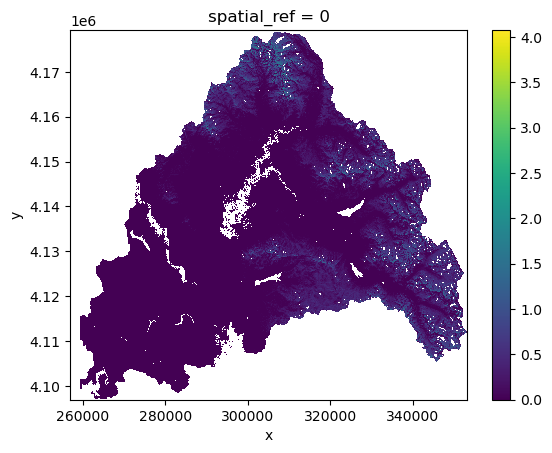

In [22]:
print(aso_march_28.mean().values)
aso_march_28.plot()

0.062992476


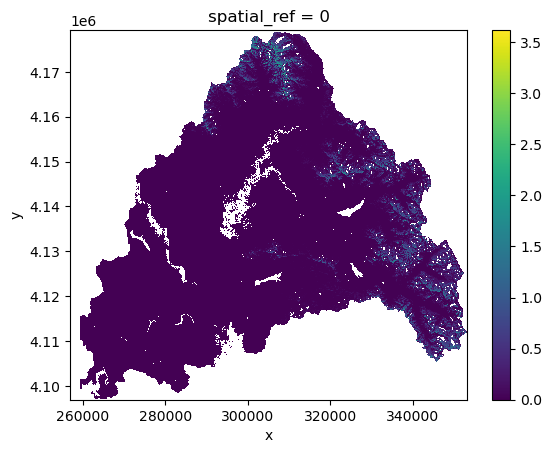

In [23]:
print(aso_may_18.mean().values)
aso_may_18.plot()

In [24]:
def area_m2_acres(dem_bin,aso_data_1,aso_site_name,applyMask = True):
    """
    Creates dictionary of different elevation bins in acres.
    Input:
      dem_bin: xarray dataset with elevation bins.
      aso_data_1: xarray dataset of aso flights.
      applyMask: python boolean to indicate whether aso common mask is being applied.
    Output:
      area_dict: dictionary of different elevation bins in acres.
    """
    # pull out common mask from aso data.
    mask = (~aso_data_1.aso_swe[-1].isnull()).values

    area_dict = {}
    for i in range(dem_bin.shape[0]):
        if applyMask:
            arr = dem_bin[i].where(mask).values.flatten()
        else:
            arr = dem_bin[i].values.flatten()
        count = len(arr[~np.isnan(arr)])
        m2 = count * 50 * 50
        acres = m2 * 0.000247105
        if aso_site_name in ['USCATM','USCASJ']:
          if dem_bin.elev[i].values == '<7000':
              area_dict['<7k'] = acres
          elif dem_bin.elev[i].values == '7000-8000':
              area_dict['7k-8k'] = acres
          elif dem_bin.elev[i].values == '8000-9000':
              area_dict['8k-9k'] = acres
          elif dem_bin.elev[i].values == '9000-10000':
              area_dict['9k-10k'] = acres
          elif dem_bin.elev[i].values == '10000-11000':
              area_dict['10k-11k'] = acres
          elif dem_bin.elev[i].values == '11000-12000':
              area_dict['11k-12k'] = acres
          elif dem_bin.elev[i].values == '>12000':
              area_dict['>12k'] = acres
          elif dem_bin.elev[i].values == 'total':
              area_dict['Total'] = acres
        elif aso_site_name == 'USCOBR':
          if dem_bin.elev[i].values == '<9000':
              area_dict['<9k'] = acres
          elif dem_bin.elev[i].values == '9000-10000':
              area_dict['9k-10k'] = acres
          elif dem_bin.elev[i].values == '10000-11000':
              area_dict['10k-11k'] = acres
          elif dem_bin.elev[i].values == '11000-12000':
              area_dict['11k-12k'] = acres
          elif dem_bin.elev[i].values == '12000-13000':
              area_dict['12k-13k'] = acres
          elif dem_bin.elev[i].values == '>13000':
              area_dict['>13k'] = acres
          elif dem_bin.elev[i].values == 'total':
              area_dict['Total'] = acres
        elif aso_site_name == 'USCOGE':
          if dem_bin.elev[i].values == '<9000':
              area_dict['<9k'] = acres
          elif dem_bin.elev[i].values == '9000-10000':
              area_dict['9k-10k'] = acres
          elif dem_bin.elev[i].values == '10000-11000':
              area_dict['10k-11k'] = acres
          elif dem_bin.elev[i].values == '11000-12000':
              area_dict['11k-12k'] = acres
          elif dem_bin.elev[i].values == '>12000':
              area_dict['>12k'] = acres
          elif dem_bin.elev[i].values == 'total':
              area_dict['Total'] = acres
    return area_dict

area_dict = area_m2_acres(dem_bin.dem_bin,aso_spatial_ds,aso_site_name,applyMask = True)
area_dict

{'<7k': 447711.01662500005,
 '7k-8k': 130347.26973750001,
 '8k-9k': 123291.1864625,
 '9k-10k': 122928.559875,
 '10k-11k': 94502.8362,
 '11k-12k': 65914.023225,
 '>12k': 13537.029662500001,
 'Total': 998232.5395500001}

In [25]:
area_ref_dict = {}
for elev in dem_bin.dem_bin.elev.values:
    if elev == '<7000':
        val = '<7k'
    elif elev == '7000-8000':
        val = '7k-8k'
    elif elev == '8000-9000':
        val = '8k-9k'
    elif elev == '9000-10000':
        val = '9k-10k'
    elif elev == '10000-11000':
        val = '10k-11k'
    elif elev == '11000-12000':
        val = '11k-12k'
    elif elev == '>12000':
        val = '>12k'
    elif elev == 'total':
        val = 'Total'
    area_ref_dict[str(elev)] = val
area_ref_dict

{'<7000': '<7k',
 '7000-8000': '7k-8k',
 '8000-9000': '8k-9k',
 '9000-10000': '9k-10k',
 '10000-11000': '10k-11k',
 '11000-12000': '11k-12k',
 '>12000': '>12k',
 'total': 'Total'}

In [26]:
# current wy aso.

current_swe, current_dates = current_wy_aso_basin_mean(aso_site_name,
                                               water_year,
                                               aso_spatial_ds,
                                               shape_proj_gdf,
                                               area_dict)

ASO_50M_SWE_USCASJ_20260127.tif
Initial Shape: (1657, 1931)
ASO_50M_SWE_USCASJ_20260303.tif
Initial Shape: (1648, 1922)
ASO_50M_SWE_USCASJ_20260429.tif
Initial Shape: (1648, 1922)
ASO_50M_SWE_USCASJ_20260518.tif
Initial Shape: (1648, 1922)
ASO_50M_SWE_USCASJ_20260328.tif
Initial Shape: (1648, 1922)


In [27]:
current_swe, current_dates,aso_mean_swe_df = current_wy_aso_mean_elev(aso_site_name,
                                               water_year,
                                               aso_spatial_ds,
                                               dem_bin.dem_bin,
                                               shape_proj_gdf,
                                               area_dict,
                                               area_ref_dict,
                                               )

ASO_50M_SWE_USCASJ_20260127.tif
Initial Shape: (1657, 1931)


Initial Shape: (1657, 1931)
Initial Shape: (1657, 1931)
Initial Shape: (1657, 1931)
Initial Shape: (1657, 1931)
Initial Shape: (1657, 1931)
Initial Shape: (1657, 1931)
Initial Shape: (1657, 1931)
ASO_50M_SWE_USCASJ_20260303.tif
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
ASO_50M_SWE_USCASJ_20260429.tif
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
ASO_50M_SWE_USCASJ_20260518.tif
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
Initial Shape: (1648, 1922)
ASO_50M_SWE_USCASJ_20260328.tif
Init

In [28]:
aso_mean_swe_df['Date'] = pd.to_datetime(aso_mean_swe_df['Date'])
aso_mean_swe_df['mean_swe'] /= 1000
aso_mean_swe_df

,Date,elev,mean_swe
0,2026-01-27,<7000,1.643416e+01
1,2026-01-27,7000-8000,6.498861e+01
2,2026-01-27,8000-9000,1.177588e+02
3,2026-01-27,9000-10000,1.478655e+02
4,2026-01-27,10000-11000,1.273727e+02
5,2026-01-27,11000-12000,8.337089e+01
6,2026-01-27,>12000,1.171944e+01
7,2026-01-27,total,5.710520e+02
8,2026-03-03,<7000,4.169818e+01
9,2026-03-03,7000-8000,9.656945e+01


## mean SWE by elevation

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '<7000'),
  Text(1, 0, '7000-8000'),
  Text(2, 0, '8000-9000'),
  Text(3, 0, '9000-10000'),
  Text(4, 0, '10000-11000'),
  Text(5, 0, '11000-12000'),
  Text(6, 0, '>12000')])

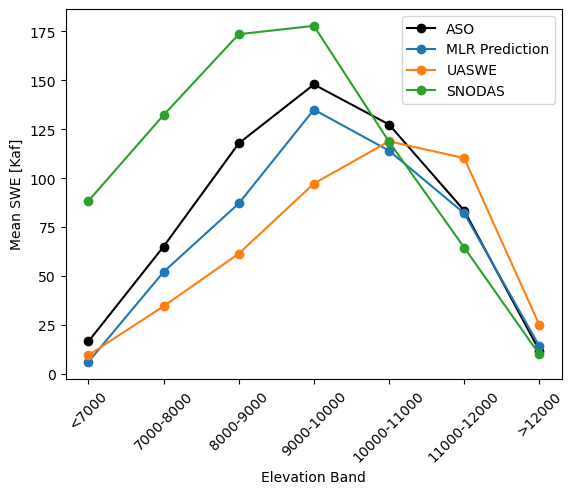

In [29]:
import matplotlib.pyplot as plt
date = '2026-01-27'
ref_dict_rev = {value: key for key, value in area_ref_dict.items()}

df_aso_date = aso_mean_swe_df[(aso_mean_swe_df['Date'] == np.datetime64(date))][['elev','mean_swe']].set_index('elev').T
uaswe_date = uaswe_acreFt_df[uaswe_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
snodas_date = snodas_acreFt_df[snodas_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
uaswe_date /= 1000
snodas_date /= 1000
prediction_date = prediction_impute_acreFt_df[(prediction_impute_acreFt_df['Date'] == np.datetime64(date)) & (prediction_acreFt_df['Training Infer NaNs'] == 'predict NaNs')].set_index('Date')
prediction_date = prediction_date[['<7k','7k-8k','8k-9k','9k-10k','10k-11k','11k-12k','>12k','Basin']]
prediction_date.rename({'Basin':'total'},inplace = True)


plt.plot(df_aso_date.columns[0:-1],df_aso_date.values.reshape(8,)[0:-1],color = 'black',linestyle = '-',marker ='o',label = 'ASO')
plt.plot(df_aso_date.columns[0:-1],prediction_date.values.reshape(8,)[0:-1],color = 'C0',linestyle = '-',marker ='o',label = 'MLR Prediction')
plt.plot(df_aso_date.columns[0:-1],uaswe_date.values.reshape(8,)[0:-1],color = 'C1',linestyle = '-',marker ='o',label = 'UASWE')
plt.plot(df_aso_date.columns[0:-1],snodas_date.values.reshape(8,)[0:-1],color = 'C2',linestyle = '-',marker ='o',label = 'SNODAS')
plt.legend()
plt.ylabel('Mean SWE [Kaf]')
plt.xlabel('Elevation Band')
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '<7000'),
  Text(1, 0, '7000-8000'),
  Text(2, 0, '8000-9000'),
  Text(3, 0, '9000-10000'),
  Text(4, 0, '10000-11000'),
  Text(5, 0, '11000-12000'),
  Text(6, 0, '>12000')])

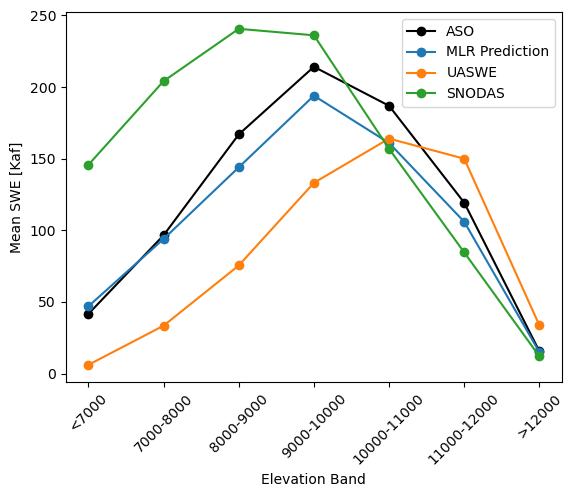

In [30]:
import matplotlib.pyplot as plt
date = '2026-03-03'
ref_dict_rev = {value: key for key, value in area_ref_dict.items()}

df_aso_date = aso_mean_swe_df[(aso_mean_swe_df['Date'] == np.datetime64(date))][['elev','mean_swe']].set_index('elev').T
uaswe_date = uaswe_acreFt_df[uaswe_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
snodas_date = snodas_acreFt_df[snodas_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
uaswe_date /= 1000
snodas_date /= 1000
prediction_date = prediction_impute_acreFt_df[(prediction_impute_acreFt_df['Date'] == np.datetime64(date)) & (prediction_acreFt_df['Training Infer NaNs'] == 'predict NaNs')].set_index('Date')
prediction_date = prediction_date[['<7k','7k-8k','8k-9k','9k-10k','10k-11k','11k-12k','>12k','Basin']]
prediction_date.rename({'Basin':'total'},inplace = True)


plt.plot(df_aso_date.columns[0:-1],df_aso_date.values.reshape(8,)[0:-1],color = 'black',linestyle = '-',marker ='o',label = 'ASO')
plt.plot(df_aso_date.columns[0:-1],prediction_date.values.reshape(8,)[0:-1],color = 'C0',linestyle = '-',marker ='o',label = 'MLR Prediction')
plt.plot(df_aso_date.columns[0:-1],uaswe_date.values.reshape(8,)[0:-1],color = 'C1',linestyle = '-',marker ='o',label = 'UASWE')
plt.plot(df_aso_date.columns[0:-1],snodas_date.values.reshape(8,)[0:-1],color = 'C2',linestyle = '-',marker ='o',label = 'SNODAS')
plt.legend()
plt.ylabel('Mean SWE [Kaf]')
plt.xlabel('Elevation Band')
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '<7000'),
  Text(1, 0, '7000-8000'),
  Text(2, 0, '8000-9000'),
  Text(3, 0, '9000-10000'),
  Text(4, 0, '10000-11000'),
  Text(5, 0, '11000-12000'),
  Text(6, 0, '>12000')])

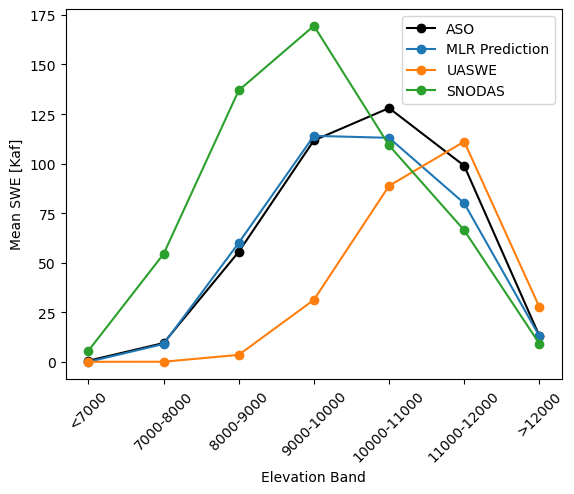

In [31]:
import matplotlib.pyplot as plt
date = '2026-03-28'
ref_dict_rev = {value: key for key, value in area_ref_dict.items()}

df_aso_date = aso_mean_swe_df[(aso_mean_swe_df['Date'] == np.datetime64(date))][['elev','mean_swe']].set_index('elev').T
uaswe_date = uaswe_acreFt_df[uaswe_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
snodas_date = snodas_acreFt_df[snodas_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
uaswe_date /= 1000
snodas_date /= 1000
prediction_date = prediction_impute_acreFt_df[(prediction_impute_acreFt_df['Date'] == np.datetime64(date)) & (prediction_acreFt_df['Training Infer NaNs'] == 'predict NaNs')].set_index('Date')
prediction_date = prediction_date[['<7k','7k-8k','8k-9k','9k-10k','10k-11k','11k-12k','>12k','Basin']]
prediction_date.rename({'Basin':'total'},inplace = True)


plt.plot(df_aso_date.columns[0:-1],df_aso_date.values.reshape(8,)[0:-1],color = 'black',linestyle = '-',marker ='o',label = 'ASO')
plt.plot(df_aso_date.columns[0:-1],prediction_date.values.reshape(8,)[0:-1],color = 'C0',linestyle = '-',marker ='o',label = 'MLR Prediction')
plt.plot(df_aso_date.columns[0:-1],uaswe_date.values.reshape(8,)[0:-1],color = 'C1',linestyle = '-',marker ='o',label = 'UASWE')
plt.plot(df_aso_date.columns[0:-1],snodas_date.values.reshape(8,)[0:-1],color = 'C2',linestyle = '-',marker ='o',label = 'SNODAS')
plt.legend()
plt.ylabel('Mean SWE [Kaf]')
plt.xlabel('Elevation Band')
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '<7000'),
  Text(1, 0, '7000-8000'),
  Text(2, 0, '8000-9000'),
  Text(3, 0, '9000-10000'),
  Text(4, 0, '10000-11000'),
  Text(5, 0, '11000-12000'),
  Text(6, 0, '>12000')])

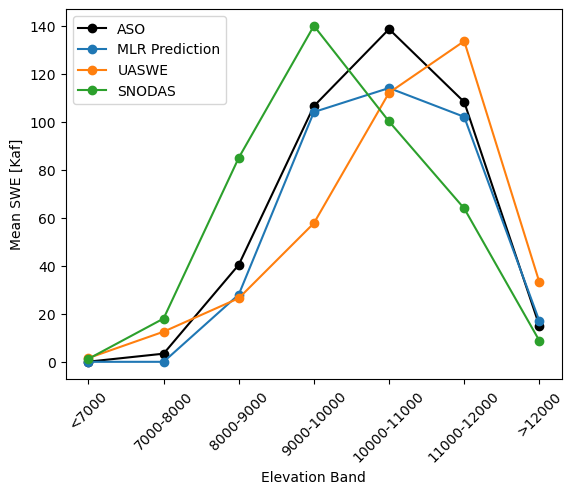

In [32]:
import matplotlib.pyplot as plt
date = '2026-04-29'
ref_dict_rev = {value: key for key, value in area_ref_dict.items()}

df_aso_date = aso_mean_swe_df[(aso_mean_swe_df['Date'] == np.datetime64(date))][['elev','mean_swe']].set_index('elev').T
uaswe_date = uaswe_acreFt_df[uaswe_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
snodas_date = snodas_acreFt_df[snodas_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
uaswe_date /= 1000
snodas_date /= 1000
prediction_date = prediction_impute_acreFt_df[(prediction_impute_acreFt_df['Date'] == np.datetime64(date)) & (prediction_acreFt_df['Training Infer NaNs'] == 'predict NaNs')].set_index('Date')
prediction_date = prediction_date[['<7k','7k-8k','8k-9k','9k-10k','10k-11k','11k-12k','>12k','Basin']]
prediction_date.rename({'Basin':'total'},inplace = True)


plt.plot(df_aso_date.columns[0:-1],df_aso_date.values.reshape(8,)[0:-1],color = 'black',linestyle = '-',marker ='o',label = 'ASO')
plt.plot(df_aso_date.columns[0:-1],prediction_date.values.reshape(8,)[0:-1],color = 'C0',linestyle = '-',marker ='o',label = 'MLR Prediction')
plt.plot(df_aso_date.columns[0:-1],uaswe_date.values.reshape(8,)[0:-1],color = 'C1',linestyle = '-',marker ='o',label = 'UASWE')
plt.plot(df_aso_date.columns[0:-1],snodas_date.values.reshape(8,)[0:-1],color = 'C2',linestyle = '-',marker ='o',label = 'SNODAS')
plt.legend()
plt.ylabel('Mean SWE [Kaf]')
plt.xlabel('Elevation Band')
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '<7000'),
  Text(1, 0, '7000-8000'),
  Text(2, 0, '8000-9000'),
  Text(3, 0, '9000-10000'),
  Text(4, 0, '10000-11000'),
  Text(5, 0, '11000-12000'),
  Text(6, 0, '>12000')])

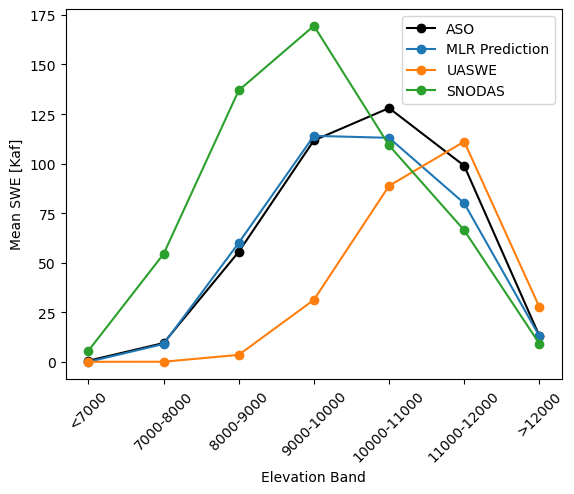

In [33]:
import matplotlib.pyplot as plt
date = '2026-03-28'
ref_dict_rev = {value: key for key, value in area_ref_dict.items()}

df_aso_date = aso_mean_swe_df[(aso_mean_swe_df['Date'] == np.datetime64(date))][['elev','mean_swe']].set_index('elev').T
uaswe_date = uaswe_acreFt_df[uaswe_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
snodas_date = snodas_acreFt_df[snodas_acreFt_df['Date'] == np.datetime64(date)].set_index('Date')
uaswe_date /= 1000
snodas_date /= 1000
prediction_date = prediction_impute_acreFt_df[(prediction_impute_acreFt_df['Date'] == np.datetime64(date)) & (prediction_acreFt_df['Training Infer NaNs'] == 'predict NaNs')].set_index('Date')
prediction_date = prediction_date[['<7k','7k-8k','8k-9k','9k-10k','10k-11k','11k-12k','>12k','Basin']]
prediction_date.rename({'Basin':'total'},inplace = True)


plt.plot(df_aso_date.columns[0:-1],df_aso_date.values.reshape(8,)[0:-1],color = 'black',linestyle = '-',marker ='o',label = 'ASO')
plt.plot(df_aso_date.columns[0:-1],prediction_date.values.reshape(8,)[0:-1],color = 'C0',linestyle = '-',marker ='o',label = 'MLR Prediction')
plt.plot(df_aso_date.columns[0:-1],uaswe_date.values.reshape(8,)[0:-1],color = 'C1',linestyle = '-',marker ='o',label = 'UASWE')
plt.plot(df_aso_date.columns[0:-1],snodas_date.values.reshape(8,)[0:-1],color = 'C2',linestyle = '-',marker ='o',label = 'SNODAS')
plt.legend()
plt.ylabel('Mean SWE [Kaf]')
plt.xlabel('Elevation Band')
plt.xticks(rotation = 45)

In [34]:
uaswe_acreFt_df

,Date,<7000,7000-8000,8000-9000,9000-10000,10000-11000,11000-12000,>12000,total
0,2025-10-01,0.000000,0.000000,0.000000,0.006341,19.058593,94.173239,53.294698,161.777201
1,2025-10-02,0.000000,0.000000,0.000000,0.000000,3.509576,36.466341,20.121470,58.307857
2,2025-10-03,0.000000,0.000000,0.000000,6.491289,218.649863,328.867069,89.238105,631.962348
3,2025-10-04,3.602291,309.921674,1283.459254,1991.673118,2085.104935,1920.243168,428.883565,7968.336821
4,2025-10-05,0.006361,28.307558,271.484799,761.097819,1562.662487,1803.438987,423.606833,4793.089290
...,...,...,...,...,...,...,...,...,...
224,2026-05-31,0.006361,20.086660,457.694391,4198.462038,38626.549778,84751.466032,26799.331320,151804.771900
225,2026-06-01,0.000000,0.000000,53.735024,3663.177864,42529.522263,92342.902561,28843.623852,164128.067786
226,2026-06-02,0.000000,0.000000,39.700406,2907.146718,38331.304788,87554.474738,28002.822573,153670.632489
227,2026-06-03,0.000000,0.000000,24.682220,2130.829538,33014.007415,80930.986582,26790.494908,139920.669971


In [35]:
aso_mean_swe_df[aso_mean_swe_df['elev'] == 'total']

,Date,elev,mean_swe
7,2026-01-27,total,571.051978
15,2026-03-03,total,841.307578
23,2026-04-29,total,412.093152
31,2026-05-18,total,206.299272
39,2026-03-28,total,417.292264


Text(0.5, 0, 'Date')

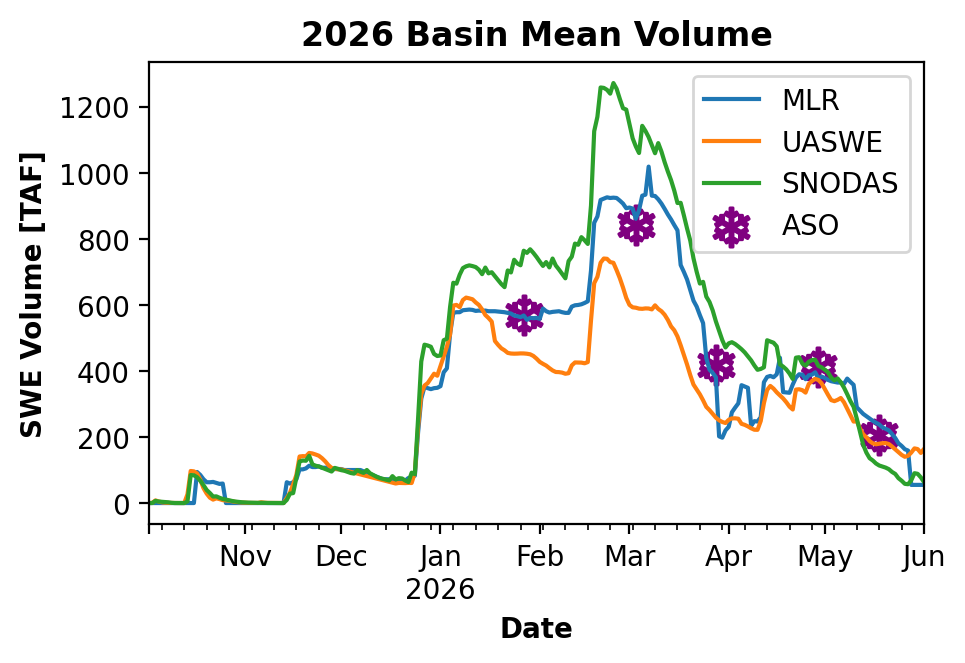

In [36]:
fig,ax = plt.subplots(dpi = 200,figsize = (5,3))
prediction_impute_acreFt_old_df[prediction_impute_acreFt_old_df['Training Infer NaNs'] == 'predict NaNs'][['Date','Basin']].plot(ax=ax,x='Date',y = 'Basin',label = 'MLR')
ax.plot(uaswe_acreFt_df.Date,uaswe_acreFt_df.total/1000,color = 'C1',label = 'UASWE')
ax.plot(snodas_acreFt_df.Date,snodas_acreFt_df.total/1000,color = 'C2',label = 'SNODAS')
l5 = ax.scatter(
        aso_mean_swe_df[aso_mean_swe_df['elev'] == 'total'].Date, aso_mean_swe_df[aso_mean_swe_df['elev'] == 'total'].mean_swe,
        label='ASO', color='purple', s=200, marker = u'$\u2744$'
)

plt.legend()
plt.title('2026 Basin Mean Volume',fontweight = 'bold')
plt.ylabel('SWE Volume [TAF]',fontweight = 'bold')
plt.xlabel('Date',fontweight = 'bold')
# prediction_impute_acreFt_df[melt_prediction_impute_acreFt_df['Training Infer NaNs'] == 'predict NaNs'][['Date','Basin']].plot(ax=ax,x='Date',y = 'Basin')

## plot with table

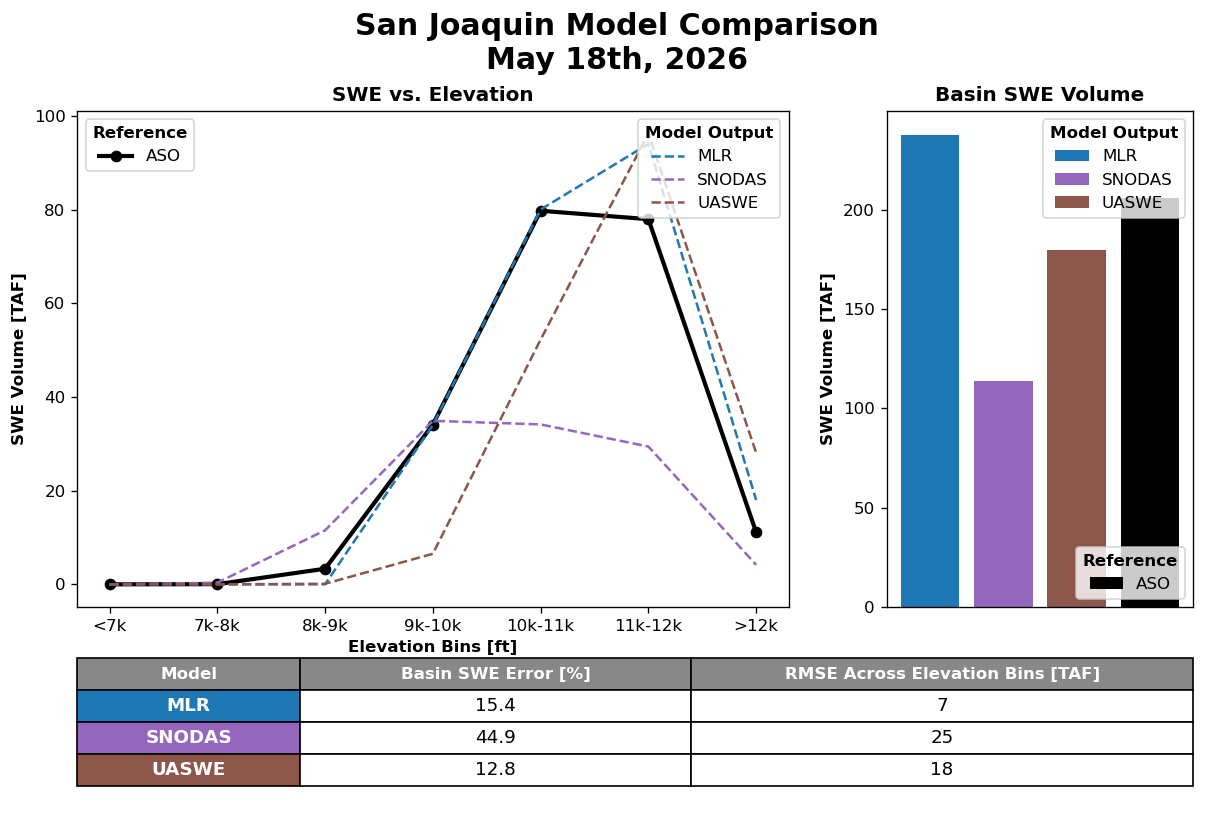

In [38]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from datetime import datetime

# ---- inputs ----
comp_date = '2026-05-18' #'2026-01-27';'2026-04-29';'2026-05-18' 
mlr_na_strategy = 'predict NaNs'   # 'drop NaNs' or 'predict NaNs'
SEASONALITY = 'season'

# ---- canonical elevation columns ----
# ASO + SNODAS + UASWE come through with long-form keys ('<7000', '7000-8000', ..., 'total').
# MLR predictions come through with short-form keys ('<7k', '7k-8k', ..., 'Basin').
# Normalize everything to short-form bins + 'Total' so downstream lookups are uniform.
elev_bins = ['<7k', '7k-8k', '8k-9k', '9k-10k', '10k-11k', '11k-12k', '>12k']

def _to_canonical(df):
    rename = {c: area_ref_dict[c] for c in df.columns if c in area_ref_dict}
    if 'Basin' in df.columns:
        rename['Basin'] = 'Total'
    return df.rename(columns=rename)

# ---- per-date slices ----
df_aso_date = _to_canonical(
    aso_mean_swe_df[aso_mean_swe_df['Date'] == np.datetime64(comp_date)]
    [['elev', 'mean_swe']].set_index('elev').T
)
uaswe_date = _to_canonical(
    uaswe_acreFt_df[uaswe_acreFt_df['Date'] == np.datetime64(comp_date)].set_index('Date') / 1000.0
)
snodas_date = _to_canonical(
    snodas_acreFt_df[snodas_acreFt_df['Date'] == np.datetime64(comp_date)].set_index('Date') / 1000.0
)
if SEASONALITY == 'season':
    mlr_date = _to_canonical(
        prediction_impute_acreFt_old_df[
            (prediction_impute_acreFt_old_df['Date'] == np.datetime64(comp_date))
            & (prediction_impute_acreFt_old_df['Training Infer NaNs'] == mlr_na_strategy)
        ].set_index('Date')
    )
elif SEASONALITY == 'accum':
    mlr_date = _to_canonical(
        accum_prediction_impute_acreFt_df[
            (accum_prediction_impute_acreFt_df['Date'] == np.datetime64(comp_date))
            & (accum_prediction_impute_acreFt_df['Training Infer NaNs'] == mlr_na_strategy)
        ].set_index('Date')
    )
elif SEASONALITY == 'melt':
    mlr_date = _to_canonical(
        melt_prediction_impute_acreFt_df[
            (melt_prediction_impute_acreFt_df['Date'] == np.datetime64(comp_date))
            & (melt_prediction_impute_acreFt_df['Training Infer NaNs'] == mlr_na_strategy)
        ].set_index('Date')
    )

def _bins(df):
    return df[elev_bins].values.flatten()
def _total(df):
    return float(df['Total'].values[0])

aso_bin_vals = _bins(df_aso_date)
aso_total = _total(df_aso_date)

mlr_label = 'MLR' if mlr_na_strategy == 'drop NaNs' else 'MLR'
models = [
    (mlr_label, 'tab:blue',   _bins(mlr_date),    _total(mlr_date)),
    ('SNODAS',  'tab:purple', _bins(snodas_date), _total(snodas_date)),
    ('UASWE',   'tab:brown',  _bins(uaswe_date),  _total(uaswe_date)),
]

# ---- KPIs ----
kpi_rows = []
for name, color, bin_vals, total in models:
    acc_pct = abs(total - aso_total) / aso_total * 100.0
    rmse = float(np.sqrt(np.mean((bin_vals - aso_bin_vals) ** 2)))
    kpi_rows.append((name, color, acc_pct, rmse))

# ---- title pieces ----
basin_label = {
    'USCASJ': 'San Joaquin',
    'USCATM': 'Tuolumne',
    'USCOBR': 'Blue River',
    'USCOGE': 'Gunnison',
}.get(aso_site_name, aso_site_name)

date_obj = datetime.strptime(comp_date, '%Y-%m-%d')
day = date_obj.day
suffix = 'th' if 10 <= day % 100 <= 20 else {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
title_date = date_obj.strftime(f'%B {day}{suffix}, %Y')

# ---- layout ----
fig = plt.figure(figsize=(12, 7.5), dpi=120)
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.0, 0.3], hspace=0.15, wspace=0.32)
ax_line = fig.add_subplot(gs[0, :2])
ax_bar = fig.add_subplot(gs[0, 2])
ax_tbl = fig.add_subplot(gs[1, :])
fig.suptitle(f'{basin_label} Model Comparison\n{title_date}', fontsize=18, fontweight='bold', y=0.99)

# ---- SWE vs. Elevation ----
aso_line, = ax_line.plot(elev_bins, aso_bin_vals, color='black', lw=2.5, marker='o', label='ASO')
model_lines = []
for name, color, bin_vals, _ in models:
    ln, = ax_line.plot(elev_bins, bin_vals, color=color, linestyle='--', label=name)
    model_lines.append(ln)
ax_line.set_title('SWE vs. Elevation', fontweight='bold')
ax_line.set_xlabel('Elevation Bins [ft]', fontweight='bold')
ax_line.set_ylabel('SWE Volume [TAF]', fontweight='bold')
leg1 = ax_line.legend(handles=[aso_line], title='Reference', loc='upper left',
                      title_fontproperties={'weight': 'bold'})
ax_line.add_artist(leg1)
ax_line.legend(handles=model_lines, title='Model Output', loc='upper right',
               title_fontproperties={'weight': 'bold'})

# ---- Total Basin SWE Volume ----
bar_labels = [m[0] for m in models] + ['ASO']
bar_colors = [m[1] for m in models] + ['black']
bar_values = [m[3] for m in models] + [aso_total]
ax_bar.bar(range(len(bar_labels)), bar_values, color=bar_colors)
ax_bar.set_xticks([])
ax_bar.set_title('Basin SWE Volume', fontweight='bold')
ax_bar.set_ylabel('SWE Volume [TAF]', fontweight='bold')
model_handles = [Patch(facecolor=m[1], label=m[0]) for m in models]
leg_models = ax_bar.legend(handles=model_handles, title='Model Output', loc='upper right',
                           title_fontproperties={'weight': 'bold'})
ax_bar.add_artist(leg_models)
ax_bar.legend(handles=[Patch(facecolor='black', label='ASO')],
              title='Reference', loc='lower right',
              title_fontproperties={'weight': 'bold'})

# ---- KPI table ----
ax_tbl.set_axis_off()
# ax_tbl.set_title('KPI Results', fontweight='bold', pad=10)
table_data = [[name, f'{acc:.1f}', f'{rmse:.0f}'] for name, _, acc, rmse in kpi_rows]
tbl = ax_tbl.table(
    cellText=table_data,
    colLabels=['Model', 'Basin SWE Error [%]', 'RMSE Across Elevation Bins [TAF]'],
    colWidths=[0.20, 0.35, 0.45],
    cellLoc='center',
    loc='upper center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)
for col_idx in range(3):
    header = tbl[(0, col_idx)]
    header.set_facecolor('#888888')
    header.set_text_props(color='white', weight='bold', fontsize=10)
for row_idx, (_, color, _, _) in enumerate(kpi_rows, start=1):
    cell = tbl[(row_idx, 0)]
    cell.set_facecolor(color)
    cell.set_text_props(color='white', weight='bold')

plt.show()

# Preprocessing

In [ ]:
aso_spatial_test,aso_tseries_test,aso_spatial_train,aso_tseries_train,obs_data_train,obs_data_qa = preprocessing.train_test_split(aso_spatial_ds,
                                                                                                  aso_tseries_ds,
                                                                                                  obs_data_train_lst,
                                                                                                  water_year)

df_sum_total = preprocessing.combine_aso_insitu(obs_data_train,
                         aso_tseries_train['aso_swe'],
                         elev_idx = -1, # total = -1
                        )
    
drop_na_df,all_pils,baseline_pils = preprocessing.generate_drop_NaNs_table(df_sum_total,
                                                                       obs_data_qa)

# pillows = [i for i in pillows if i not in exclude_pillows]

historic_vals_df = preprocessing.create_qa_tables(obs_data_train_lst, [], isQA=False)

impute_dir = f'{mlrPred_dir}imputation/'
    
obs_data_impute,pils_removed,impute_na_df = preprocessing.imputation_w_pillows(df_sum_total,
                                                                               all_pils,
                                                                               obs_data_qa,
                                                                               aso_site_name,
                                                                               water_year,
                                                                               impute_dir,
                                                                               obs_threshold = 0.50,
                                                                               saveImputeCSV = True,
)

obs_data_impute_sm,pils_removed_sm,impute_na_df_sm = preprocessing.imputation_w_snowmodel(
                                            df_sum_total,
                                            all_pils,
                                            obs_data_qa,
                                            sm_train_ds,
                                            aso_site_name,
                                            water_year,
                                            impute_dir,
                                            obs_threshold = 0.50,
                                            saveImputeCSV = True,
                                            train_start_year = 2013,
                                            predictor_vars=("swed_best", "swed_second", "swed_third"),
                                        )

# Run Single Model

## model inputs

In [ ]:
elev_band,modelID = 7,0
isSplit,isAccum,isImpute,isMean = True, True, True, False
pillowImputation_ = True
add_zeroASO,pickledir = True, None
showOutput = False
t_input = '2026-01-28'


In [ ]:
exclude_pillows = []

## Model Simulation

## Best case scenario

In [ ]:

importlib.reload(lm_model)
importlib.reload(preprocessing)
print('RUNNING MLR MODEL ...\n')

start = time.time()

t_idx = [i for i, t in enumerate(obs_data_test_lst[0].time.values) if str(pd.to_datetime(t))[:10] == t_input][0]

current_date_np = obs_data_test_lst[0].time[t_idx].values
current_date = datetime(pd.to_datetime(current_date_np).year,pd.to_datetime(current_date_np).month,pd.to_datetime(current_date_np).day)
    

current_vals_df,all_pils_QA,baseline_pils_,df_qa_table = preprocessing.process_daily_qa(
                                                                   t_idx,
                                                                   obs_data_test_lst_raw,
                                                                   obs_data_test_lst,
                                                                   baseline_pils,
                                                                   exclude_pillows,
                                                                   printOutput = True,
                                                                   isBestCase = True
                                                                              )


df_split,summary_dict_model,aso_tseries_2,obs_data_6,rmse = lm_model.run_mlr_train_predict(aso_tseries_train.aso_swe,obs_data_qa,elev_band,all_pils,all_pils_QA,df_sum_total,baseline_pils,start_wy,end_wy,
                         aso_site_name,isSplit,isAccum,isImpute,isMean,current_date,
                         modelID,QA_flag,model_type = 'MLR',showOutput = False,isCombination = True,
                         saveValidation = True,pillowImputation = pillowImputation_,
                         ds_model= sm_train_ds)

selected_pils = summary_dict_model[modelID]['model_features']['features']
print('Best case pillow selection:',selected_pils)




In [ ]:

importlib.reload(lm_model)
importlib.reload(preprocessing)
print('RUNNING MLR MODEL ...\n')
t_input = '2026-01-29'
start = time.time()

t_idx = [i for i, t in enumerate(obs_data_test_lst[0].time.values) if str(pd.to_datetime(t))[:10] == t_input][0]

current_date_np = obs_data_test_lst[0].time[t_idx].values
current_date = datetime(pd.to_datetime(current_date_np).year,pd.to_datetime(current_date_np).month,pd.to_datetime(current_date_np).day)
    

current_vals_df,all_pils_QA,baseline_pils_,df_qa_table = preprocessing.process_daily_qa(
                                                                   t_idx,
                                                                   obs_data_test_lst_raw,
                                                                   obs_data_test_lst,
                                                                   baseline_pils,
                                                                   exclude_pillows,
                                                                   printOutput = True,
                                                                   isBestCase = True
                                                                              )


df_split,summary_dict_model,aso_tseries_2,obs_data_6,rmse = lm_model.run_mlr_train_predict(aso_tseries_train.aso_swe,obs_data_qa,elev_band,all_pils,all_pils_QA,df_sum_total,baseline_pils,start_wy,end_wy,
                         aso_site_name,isSplit,isAccum,isImpute,isMean,current_date,
                         modelID,QA_flag,model_type = 'MLR',showOutput = False,isCombination = True,
                         saveValidation = True,pillowImputation = pillowImputation_,
                         ds_model= sm_train_ds)

selected_pils = summary_dict_model[modelID]['model_features']['features']
print('Best case pillow selection:',selected_pils)




In [ ]:
baseline_pils_

## Current Day

In [ ]:

importlib.reload(lm_model)
importlib.reload(preprocessing)
print('RUNNING MLR MODEL ...\n')

t_input = '2026-01-28'
start = time.time()

t_idx = [i for i, t in enumerate(obs_data_test_lst[0].time.values) if str(pd.to_datetime(t))[:10] == t_input][0]

# # for t_idx in range(1,obs_data_test_lst[0].time.shape[0]):
current_date_np = obs_data_test_lst[0].time[t_idx].values
current_date = datetime(pd.to_datetime(current_date_np).year,pd.to_datetime(current_date_np).month,pd.to_datetime(current_date_np).day)
    

current_vals_df,all_pils_QA,baseline_pils_,df_qa_table = preprocessing.process_daily_qa(
                                                                   t_idx,
                                                                   obs_data_test_lst_raw,
                                                                   obs_data_test_lst,
                                                                   baseline_pils,
                                                                   exclude_pillows,
                                                                   printOutput = True,
                                                                              )


df_split,summary_dict_model,aso_tseries_2,obs_data_6,rmse = lm_model.run_mlr_train_predict(aso_tseries_train.aso_swe,obs_data_qa,elev_band,all_pils,all_pils_QA,df_sum_total,baseline_pils_,start_wy,end_wy,
                         aso_site_name,isSplit,isAccum,isImpute,isMean,current_date,
                         modelID,QA_flag,model_type = 'MLR',showOutput = True,isCombination = True,
                         saveValidation = True,pillowImputation = pillowImputation_,
                         ds_model= sm_train_ds)

selected_pils = summary_dict_model[modelID]['model_features']['features']


elev_vals = dem_bin.dem_bin[elev_band].values.flatten()
# count of valid grids.
count = len(elev_vals[~np.isnan(elev_vals)])
# count to m2.
area_m2 = count * 50 * 50

yhat_mm,df_train,yhat_test = lm_model.run_daily_prediction(df_split,current_vals_df.reset_index(names='time'),selected_pils,modelID,conversion = 0,
                                        area_m2 = area_m2,outdir = pickledir,add_zeroASO = add_zeroASO)
# predictions in acre ft
yhat_acreft,df_train,yhat_test = lm_model.run_daily_prediction(df_split,current_vals_df.reset_index(names='time'),selected_pils,modelID,conversion = 2,
                                        area_m2 = area_m2,outdir = pickledir,add_zeroASO = add_zeroASO)
# add prediction to summary dictionary.
## predictions mm
summary_dict_model[modelID]['prediction']['mm'].append(float(yhat_mm))
## prediction acre-ft
summary_dict_model[modelID]['prediction']['acre_ft'].append(float(yhat_acreft))
print('elev_band',elev_band,'selected_pils',selected_pils)
print('predictions mm:',yhat_mm, 'acre_FT:',yhat_acreft)


In [ ]:

importlib.reload(lm_model)
importlib.reload(preprocessing)
print('RUNNING MLR MODEL ...\n')

t_input = '2026-01-29'
start = time.time()

t_idx = [i for i, t in enumerate(obs_data_test_lst[0].time.values) if str(pd.to_datetime(t))[:10] == t_input][0]

# # for t_idx in range(1,obs_data_test_lst[0].time.shape[0]):
current_date_np = obs_data_test_lst[0].time[t_idx].values
current_date = datetime(pd.to_datetime(current_date_np).year,pd.to_datetime(current_date_np).month,pd.to_datetime(current_date_np).day)
    

current_vals_df,all_pils_QA,baseline_pils_,df_qa_table = preprocessing.process_daily_qa(
                                                                   t_idx,
                                                                   obs_data_test_lst_raw,
                                                                   obs_data_test_lst,
                                                                   baseline_pils,
                                                                   exclude_pillows,
                                                                   printOutput = True,
                                                                              )


df_split,summary_dict_model,aso_tseries_2,obs_data_6,rmse = lm_model.run_mlr_train_predict(aso_tseries_train.aso_swe,obs_data_qa,elev_band,all_pils,all_pils_QA,df_sum_total,baseline_pils_,start_wy,end_wy,
                         aso_site_name,isSplit,isAccum,isImpute,isMean,current_date,
                         modelID,QA_flag,model_type = 'MLR',showOutput = True,isCombination = True,
                         saveValidation = True,pillowImputation = pillowImputation_,
                         ds_model= sm_train_ds)

selected_pils = summary_dict_model[modelID]['model_features']['features']


elev_vals = dem_bin.dem_bin[elev_band].values.flatten()
# count of valid grids.
count = len(elev_vals[~np.isnan(elev_vals)])
# count to m2.
area_m2 = count * 50 * 50

yhat_mm,df_train,yhat_test = lm_model.run_daily_prediction(df_split,current_vals_df.reset_index(names='time'),selected_pils,modelID,conversion = 0,
                                        area_m2 = area_m2,outdir = pickledir,add_zeroASO = add_zeroASO)
# predictions in acre ft
yhat_acreft,df_train,yhat_test = lm_model.run_daily_prediction(df_split,current_vals_df.reset_index(names='time'),selected_pils,modelID,conversion = 2,
                                        area_m2 = area_m2,outdir = pickledir,add_zeroASO = add_zeroASO)
# add prediction to summary dictionary.
## predictions mm
summary_dict_model[modelID]['prediction']['mm'].append(float(yhat_mm))
## prediction acre-ft
summary_dict_model[modelID]['prediction']['acre_ft'].append(float(yhat_acreft))
print('elev_band',elev_band,'selected_pils',selected_pils)
print('predictions mm:',yhat_mm, 'acre_FT:',yhat_acreft)


In [ ]:
baseline_pils_

In [ ]:
all_pils_QA

## SnowModel MLR Predictions

In [ ]:
exclude_pillows = ['KUP']

In [ ]:
importlib.reload(lm_model)
importlib.reload(preprocessing)
print('RUNNING MLR MODEL ...\n')

start = time.time()

t_idx = [i for i, t in enumerate(obs_data_test_lst[0].time.values) if str(pd.to_datetime(t))[:10] == t_input][0]

# # for t_idx in range(1,obs_data_test_lst[0].time.shape[0]):
current_date_np = obs_data_test_lst[0].time[t_idx].values
current_date = datetime(pd.to_datetime(current_date_np).year,pd.to_datetime(current_date_np).month,pd.to_datetime(current_date_np).day)
    

current_vals_df,all_pils_QA,baseline_pils_,df_qa_table = preprocessing.process_daily_qa(
                                                                   t_idx,
                                                                   obs_data_test_lst_raw,
                                                                   obs_data_test_lst,
                                                                   baseline_pils,
                                                                   exclude_pillows,
                                                                   printOutput = True,
                                                                              )


df_split,summary_dict_model,aso_tseries_2,obs_data_6,rmse = lm_model.run_mlr_train_predict(aso_tseries_train.aso_swe,obs_data_qa,elev_band,all_pils,all_pils_QA,df_sum_total,baseline_pils,start_wy,end_wy,
                         aso_site_name,isSplit,isAccum,isImpute,isMean,current_date,
                         modelID,QA_flag,model_type = 'MLR',showOutput = False,isCombination = True,
                         saveValidation = True,pillowImputation = False,ds_model = sm_train_ds)

selected_pils = summary_dict_model[modelID]['model_features']['features']


elev_vals = dem_bin.dem_bin[elev_band].values.flatten()
# count of valid grids.
count = len(elev_vals[~np.isnan(elev_vals)])
# count to m2.
area_m2 = count * 50 * 50

yhat_mm,df_train,yhat_test = lm_model.run_daily_prediction(df_split,current_vals_df.reset_index(names='time'),selected_pils,modelID,conversion = 0,
                                        area_m2 = area_m2,outdir = pickledir,add_zeroASO = add_zeroASO)
# predictions in acre ft
yhat_acreft,df_train,yhat_test = lm_model.run_daily_prediction(df_split,current_vals_df.reset_index(names='time'),selected_pils,modelID,conversion = 2,
                                        area_m2 = area_m2,outdir = pickledir,add_zeroASO = add_zeroASO)
# add prediction to summary dictionary.
## predictions mm
summary_dict_model[modelID]['prediction']['mm'].append(float(yhat_mm))
## prediction acre-ft
summary_dict_model[modelID]['prediction']['acre_ft'].append(float(yhat_acreft))
print('elev_band',elev_band,'selected_pils',selected_pils)
print('predictions mm:',yhat_mm, 'acre_FT:',yhat_acreft)


In [ ]:
bool(int('1'))

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(dpi = 200)

# Plot training values
for pil in selected_pils:
    df_split.plot(x=pil,y='aso_swe',ax=ax, label=pil, marker='o', linestyle='None')
legend1 = plt.legend(title='Training Values', title_fontproperties={'weight': 'bold'},loc = 'upper right')

plt.axhline(yhat_mm, color='gray', linewidth=0.8, linestyle='--')
# Plot test values
for pil in selected_pils:
    plt.scatter(current_vals_df[pil], yhat_mm, label=pil, marker='o',s = 90,color = 'red')
    plt.scatter(current_vals_df[pil], yhat_mm, label=pil, marker='o',s = 30)



# Add second legend for test values
custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, markeredgecolor='red', markeredgewidth=1.5)]
legend2 = plt.legend(custom_lines, ['Test Values'], loc='upper left', title='Current Prediction', title_fontproperties={'weight': 'bold'})

# Add first legend back (since creating legend2 replaces it)
ax.add_artist(legend1)

plt.xlabel('Pillow Obs [mm]',fontweight='bold')
plt.ylabel('ASO Mean SWE [mm]',fontweight='bold')
plt.title('Observations and Labels',fontweight='bold')

In [ ]:
current_vals_df.reset_index(names='time')

# Appendix

In [ ]:
importlib.reload(plotting)
plotting.html_timeseries_plot(mlr_tables,
                                  mlr_identifiers,
                                  uaswe_acreFt_df,
                                  snodas_acreFt_df,
                                  sm_acreFt_df,
                                  aso_site_name,
                                  None,
                                  train_infer = 'predict NaNs',
                                  saveFIG = False,
    )

In [ ]:
mlr_identifiers

In [ ]:
mlr_tables[2].iloc[-90]

In [ ]:
mlr_tables[5].iloc[-1]

In [ ]:
mlr_tables[8].iloc[-30]

In [ ]:
uaswe_m_df

In [ ]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(3,1,figsize=(10,8),sharex=True)
# season
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[1][mlr_tables[1]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[2].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[2][1],fontweight = 'bold')
# accum
ax[1].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[1].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[1],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[1],label=pil,linestyle = '-.')
ax[1].legend()
ax[1].set_title(mlr_identifiers[5][1],fontweight = 'bold')
# melt
ax[2].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[2].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[7][mlr_tables[7]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[2],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
for pil in [x.strip() for x in mlr_tables[8].iloc[-1]['Basin'].split(",")]:
    obs_data_test_ds[pil].plot(ax=ax[2],label=pil,linestyle = '-.')
ax[2].legend()
ax[2].set_title(mlr_identifiers[8][1],fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
importlib.reload(plotting)
df_pred_slice, df_pil_slice, df_pil_explode, df_pil_mat,diff_arr,nan_arr,diff_mask = plotting.timeseries_pillow_selection(mlr_tables,
                                mlr_identifiers,
                                uaswe_m_df,
                                snodas_m_df,
                                obs_data_test_ds_raw,
                                obs_data_test_ds,
                                start_date = '2025-10-01',
                                end_date = '2025-11-15',
                                model_type = 'accum',
                                model_units = 'mm'
                                )

In [ ]:
mlr_identifiers

In [ ]:
df_pred_slice = mlr_tables[4][(mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs') &  \
              (mlr_tables[4]['Date'] < np.datetime64('2025-11-15'))]

In [ ]:
df_pil_slice = mlr_tables[5][(mlr_tables[5]['Training Infer NaNs'] == 'predict NaNs') &  \
              (mlr_tables[5]['Date'] < np.datetime64('2025-11-15'))][['Date','Basin']]

In [ ]:
fig,ax = plt.subplots(3,1,figsize=(10,8),sharex=True)
# accum
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
# for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
#     obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[5][1],fontweight = 'bold')
ax[0].set_xlim(np.datetime64('2025-10-01'),np.datetime64('2025-11-15'))

obs_data_test_ds_raw['LLE'].plot(ax=ax[1],label='LLE',linestyle = '-')
obs_data_test_ds_raw['STL'].plot(ax=ax[1],label='STL',linestyle = '-')
obs_data_test_ds_raw['SWM'].plot(ax=ax[1],label='SWM',linestyle = '-')
obs_data_test_ds_raw['FLV'].plot(ax=ax[1],label='FLV',linestyle = '-')
ax[1].legend()
ax[1].set_ylim(-10,200)
ax[1].set_title('raw pillows',fontweight = 'bold')


obs_data_test_ds['LLE'].plot(ax=ax[2],label='LLE',linestyle = '-')
obs_data_test_ds['STL'].plot(ax=ax[2],label='STL',linestyle = '-')
obs_data_test_ds['SWM'].plot(ax=ax[2],label='SWM',linestyle = '-')
obs_data_test_ds['FLV'].plot(ax=ax[2],label='FLV',linestyle = '-')
ax[2].legend()
ax[2].set_ylim(-10,200)
ax[2].set_title('clean pillows',fontweight = 'bold')

In [ ]:
df_pil_slice

In [ ]:
obs_data_test_ds_raw.where(obs_data_test_ds_raw.time < np.datetime64('2025-10-01'))

In [ ]:
raw_df = obs_data_test_ds_raw.where(obs_data_test_ds_raw.time > np.datetime64('2025-10-01'),drop = True) \
                    .where(obs_data_test_ds_raw.time < np.datetime64('2025-11-15'),drop = True) \
                   [['LLE','STL','SWM','FLV']].to_dataframe()

test_df = obs_data_test_ds.where(obs_data_test_ds.time > np.datetime64('2025-10-01'),drop = True) \
                    .where(obs_data_test_ds.time < np.datetime64('2025-11-15'),drop = True) \
                   [['LLE','STL','SWM','FLV']].to_dataframe()

In [ ]:
diff_mask = ~(
    (raw_df == test_df) |
    (raw_df.isna() & test_df.isna())
)
diff_mask

nan_mask = ~raw_df.isna()
nan_mask

In [ ]:
df = nan_mask.copy()

# Ensure datetime + sorted
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Convert to numeric for plotting:
#   True -> 1, False -> 0, NaN -> np.nan (so it can be a separate color if you want)
arr = df.astype("float").to_numpy().T   # transpose so pillows are rows, time is cols

fig, ax = plt.subplots(figsize=(12, 3.5))

im = ax.imshow(
    arr,
    aspect="auto",
    interpolation="nearest",
    cmap = 'binary'
)

ax.set_xlabel("Date")
ax.set_ylabel("Pillow")

# Y ticks = pillows
ax.set_yticks(np.arange(df.shape[1]))
ax.set_yticklabels(df.columns)
# X ticks = dates (downsample if many)
step = max(1, len(df.index) // 12)  # ~12 ticks
xt = np.arange(0, len(df.index), step)
ax.set_xticks(xt)
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in df.index[xt]], rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# Ensure datetime
df = df_pil_slice.copy()
df["Date"] = pd.to_datetime(df["Date"])

# Split basin strings into lists
df["Pillow"] = df["Basin"].str.split(r"\s*,\s*")

# Explode to long format
df_long = df.explode("Pillow")[["Date", "Pillow"]]
# Create binary presence matrix
mat = (
    df_long
    .assign(value=1)
    .pivot(index="Pillow", columns="Date", values="value")
    .fillna(0)
    .sort_index()
)
fig,ax = plt.subplots(2,1,figsize=(10,8),sharex=False)
ax[0].plot(uaswe_m_df['Date'],uaswe_m_df['total']*1000,label='UASWE',color='black',linewidth=2,linestyle = '--')
ax[0].plot(snodas_m_df['Date'],snodas_m_df['total']*1000,label='SNODAS',color='gray',linewidth=2,linestyle = '--')
mlr_tables[4][mlr_tables[4]['Training Infer NaNs'] == 'predict NaNs'].plot(ax=ax[0],x='Date',y='Basin',color = 'red',linewidth=2,label = 'MLR Prediction')
# for pil in [x.strip() for x in mlr_tables[5].iloc[-1]['Basin'].split(",")]:
#     obs_data_test_ds[pil].plot(ax=ax[0],label=pil,linestyle = '-.')
ax[0].legend()
ax[0].set_title(mlr_identifiers[5][1],fontweight = 'bold')
ax[0].set_xlim(np.datetime64('2025-10-01'),np.datetime64('2025-11-14'))
ax[0].set_xticks([])
ax[0].set_xlabel('')

im = ax[1].imshow(
    mat.values,
    aspect="auto",
    interpolation="nearest",
    cmap = 'binary',
)

# Axis labels
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Pillow")

# Ticks
ax[1].set_yticks(range(len(mat.index)))
ax[1].set_yticklabels(mat.index)

ax[1].set_xticks(range(len(mat.columns)))
ax[1].set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in mat.columns],
    rotation=45,
    ha="right"
)

ax[1].set_title('Pillow Selection (black = selected)',fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
[d.strftime("%Y-%m-%d") for d in mat.columns]